<a href="https://colab.research.google.com/github/anaribeiro4/novo-repositorio/blob/main/Adaline..ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto: Reconhecimento de Letras com Adaline

### Detalhes Técnicos:
* **Modelo**: ADAptive Linear NEuron (Adaline)[cite: 112].
* **Aprendizagem**: Regra Delta baseada na saída linear[cite: 115, 135].
* **Ativação**: Função degrau com saídas bipolares (+1 ou -1)[cite: 115, 186].

Instalando fontes TrueType da Microsoft no sistema (aguarde)...
✓ Fontes configuradas com sucesso!

[Passo 1] Preparando diretórios das pastas...
[Passo 2] Construindo dataset inicial de imagens (20x20)...
[Passo 3] Treinando os classificadores Adaline para as 26 letras do alfabeto...
[Passo 4] Executando validação e gerando gráfico de convergência...

   RELATÓRIO DE DESEMPENHO (20x20)
Total de Amostras de Teste : 130
Total de Predições Corretas: 34
Acurácia Global do Sistema : 26.15%

Exemplos de erros cometidos pela rede (Top 5):
Esperado Predito
       U       C
       D       O
       A       L
       G       O
       I       Y


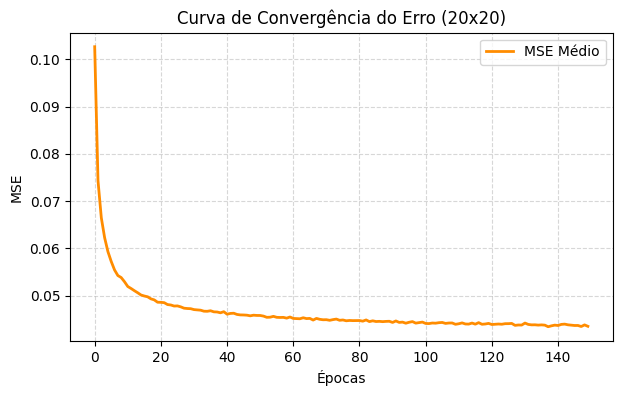

[Passo 5] Testando tolerância a falhas (Ruído Sal e Pimenta)...

      TABELA DE ROBUSTEZ COM RUÍDO            
Nível de Ruído (%)  Amostras Testadas Acurácia Obtida
                0%                130          26.15%
                5%                130          13.08%
               15%                130           6.15%
               30%                130           5.38%

     JOGO INTERATIVO: MÚLTIPLA ESCOLHA        

[Visualização da Imagem Sorteada]:
                                                           
                                                           
                                                           
                                                           
                                                           
                                                           
                                                           
                                                           
                     ██ ██ ██ ██ ██ ██                

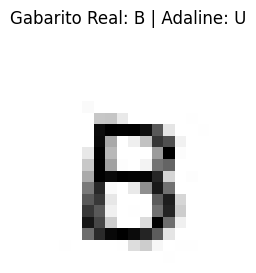

In [12]:
import os
import cv2
import random
import string
import pickle
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# --- Configuração e Instalação de Fontes no Sistema ---
print("Instalando fontes TrueType da Microsoft no sistema (aguarde)...")
try:
    # Executa os comandos de forma silenciosa para não poluir o terminal
    subprocess.run("apt-get update > /dev/null 2>&1", shell=True)
    subprocess.run("echo ttf-mscorefonts-installer msttcorefonts/accepted-mscorefonts-eula select true | debconf-set-selections", shell=True)
    subprocess.run("apt-get install -y ttf-mscorefonts-installer > /dev/null 2>&1", shell=True)
    subprocess.run("fc-cache -f -v > /dev/null 2>&1", shell=True)
    print("✓ Fontes configuradas com sucesso!")
except Exception as e:
    print(f"Aviso ao instalar fontes (pode ser ignorado se não for Linux): {e}")


# --- Funções de Preparação e Geração de Dados ---

def preparar_ambiente():
    """Cria a estrutura de pastas necessária para o projeto."""
    for pasta in ['dados/treino', 'dados/teste', 'modelos', 'resultados']:
        if not os.path.exists(pasta):
            os.makedirs(pasta)


def gerar_variacoes_letra(letra, pasta_destino, num_variacoes=10, tamanho_imagem=20):
    """Gera variações em imagem de uma letra específica alterando fonte, tamanho e rotação."""
    fontes_requisito = {
        "Arial": "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf",
        "Times New Roman": "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf",
        "Verdana": "/usr/share/fonts/truetype/msttcorefonts/Verdana.ttf",
        "Courier": "/usr/share/fonts/truetype/msttcorefonts/Courier_New.ttf"
    }
    nomes_fontes = list(fontes_requisito.keys())

    for i in range(num_variacoes):
        nome_fonte = random.choice(nomes_fontes)
        caminho_fonte = fontes_requisito[nome_fonte]
        tamanho_fonte = int(tamanho_imagem * 0.65) + random.randint(-1, 1)

        try:
            font = ImageFont.truetype(caminho_fonte, tamanho_fonte)
        except IOError:
            font = ImageFont.load_default()

        # Criar imagem com fundo branco (255)
        img = Image.new('L', (tamanho_imagem, tamanho_imagem), color=255)
        draw = ImageDraw.Draw(img)

        # Trata a compatibilidade do tamanho do texto entre versões do Pillow
        try:
            bbox = draw.textbbox((0, 0), letra, font=font)
            w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
        except AttributeError:
            w, h = draw.textsize(letra, font=font)

        # Centralização com leve deslocamento aleatório
        pos_x = (tamanho_imagem - w) // 2 + random.randint(-1, 1)
        pos_y = (tamanho_imagem - h) // 2 + random.randint(-1, 1)

        # Escreve a letra em preto (0)
        draw.text((pos_x, pos_y), letra, fill=0, font=font)

        # Aplica rotação aleatória
        angulo = random.randint(-8, 8)
        img = img.rotate(angulo, resample=Image.BICUBIC, fillcolor=255)

        nome_arquivo = f"{letra}_{nome_fonte.replace(' ', '')}_{i}.png"
        img.save(os.path.join(pasta_destino, nome_arquivo))


def construir_dataset(tamanho_imagem=20):
    """Limpa as pastas e reconstrói o dataset com imagens de treino e teste."""
    if os.path.exists('dados/treino'):
        for f in os.listdir('dados/treino'): os.remove(os.path.join('dados/treino', f))
    if os.path.exists('dados/teste'):
        for f in os.listdir('dados/teste'): os.remove(os.path.join('dados/teste', f))

    alfabeto = string.ascii_uppercase
    for letra in alfabeto:
        gerar_variacoes_letra(letra, 'dados/treino', num_variacoes=15, tamanho_imagem=tamanho_imagem)
        gerar_variacoes_letra(letra, 'dados/teste', num_variacoes=5, tamanho_imagem=tamanho_imagem)


# --- Processamento de Imagens e Extração de Características ---

def extrair_vetor_caracteristicas(caminho_imagem, tamanho_padrao=(20, 20)):
    """Lê a imagem, binariza e achata em um vetor unidimensional (0.0 ou 1.0)."""
    img = cv2.imread(caminho_imagem)
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Inverte a binarização: letra vira 255 (Branco) e fundo vira 0 (Preto)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
    resized = cv2.resize(binary, tamanho_padrao, interpolation=cv2.INTER_AREA)
    vetor_final = np.where(resized > 0, 1.0, 0.0)

    return vetor_final.flatten()


def carregar_dados_pasta(pasta, dim_atual=(20, 20)):
    """Varre a pasta extraindo as características e rótulos de todas as imagens."""
    X = []
    y = []
    for nome_arquivo in os.listdir(pasta):
        if nome_arquivo.endswith('.png'):
            letra = nome_arquivo.split('_')[0]
            vetor = extrair_vetor_caracteristicas(os.path.join(pasta, nome_arquivo), tamanho_padrao=dim_atual)
            if vetor is not None:
                X.append(vetor)
                y.append(letra)
    return np.array(X), np.array(y)


# --- Implementação do Neurônio Adaline ---

class Adaline:
    def __init__(self, n_features, lr=0.001, epochs=100):
        self.lr = lr
        self.epochs = epochs
        self.w = np.random.uniform(-0.01, 0.01, n_features)
        self.b = np.random.uniform(-0.01, 0.01)
        self.historico_erros = []

    def funcao_linear(self, x):
        return np.dot(x, self.w) + self.b

    def funcao_degrau_bipolar(self, y_linear):
        return np.where(y_linear >= 0, 1, -1)

    def treinar(self, X, t):
        self.historico_erros = []
        for epoca in range(self.epochs):
            erro_quadratico_epoca = 0.0
            indices = np.arange(len(X))
            np.random.shuffle(indices)

            for idx in indices:
                x_amostra = X[idx]
                t_alvo = t[idx]

                y_linear = self.funcao_linear(x_amostra)
                erro = t_alvo - y_linear
                erro_quadratico_epoca += 0.5 * (erro ** 2)

                # Atualização dos pesos baseada na regra Delta de Widrow-Hoff
                self.w += self.lr * erro * x_amostra
                self.b += self.lr * erro

            self.historico_erros.append(erro_quadratico_epoca / len(X))


# --- Fluxo de Treinamento e Classificação Multi-classe ---

def treinar_sistema_completo(lr=0.001, epochs=100, dim_atual=(20, 20)):
    X_treino, y_treino = carregar_dados_pasta('dados/treino', dim_atual=dim_atual)

    if len(X_treino) == 0:
        return None, None

    alfabeto = list(string.ascii_uppercase)
    modelos_adaline = {}
    mse_acumulado_epocas = np.zeros(epochs)

    for letra in alfabeto:
        # Cria a saída alvo bipolar (+1 para a classe alvo, -1 para as demais)
        t_bipolar = np.where(y_treino == letra, 1, -1)
        modelo = Adaline(n_features=X_treino.shape[1], lr=lr, epochs=epochs)
        modelo.treinar(X_treino, t_bipolar)
        modelos_adaline[letra] = modelo
        mse_acumulado_epocas += np.array(modelo.historico_erros)

    with open('modelos/rede_adaline_caracteres.pkl', 'wb') as f:
        pickle.dump(modelos_adaline, f)

    return modelos_adaline, (mse_acumulado_epocas / len(alfabeto))


def classificar_caractere(vetor_caracteristicas, modelos):
    """Escolhe a letra baseando-se no maior score linear dentre todos os neurônios."""
    maior_score = float('-inf')
    letra_predita = None

    for letra, neuronio in modelos.items():
        score_linear = neuronio.funcao_linear(vetor_caracteristicas)
        if score_linear > maior_score:
            maior_score = score_linear
            letra_predita = letra

    return letra_predita


# --- Robustez, Ruídos e Testes ---

def aplicar_ruido_sal_pimenta(X_matriz, porcentagem=0.1):
    """Inverte o estado lógico de um percentual de pixels selecionados de forma aleatória."""
    X_ruidoso = X_matriz.copy()
    amostras, features = X_ruidoso.shape
    n_pixels_mudar = int(features * porcentagem)

    for i in range(amostras):
        indices = np.random.choice(features, n_pixels_mudar, replace=False)
        X_ruidoso[i, indices] = np.where(X_ruidoso[i, indices] == 1.0, 0.0, 1.0)

    return X_ruidoso


def avaliar_sistema_completo(modelos, mse_historico, dim_atual=(20, 20), exibir_grafico=True):
    X_teste, y_teste = carregar_dados_pasta('dados/teste', dim_atual=dim_atual)

    acertos = 0
    predicoes = []

    for x, alvo in zip(X_teste, y_teste):
        predicao = classificar_caractere(x, modelos)
        predicoes.append(predicao)
        if predicao == alvo:
            acertos += 1

    acuracia = (acertos / len(y_teste)) * 100

    if exibir_grafico:
        print("\n==============================================")
        print(f"   RELATÓRIO DE DESEMPENHO ({dim_atual[0]}x{dim_atual[1]})")
        print("==============================================")
        print(f"Total de Amostras de Teste : {len(y_teste)}")
        print(f"Total de Predições Corretas: {acertos}")
        print(f"Acurácia Global do Sistema : {acuracia:.2f}%")
        print("==============================================")

        df_resultados = pd.DataFrame({'Esperado': y_teste, 'Predito': predicoes})
        erros = df_resultados[df_resultados['Esperado'] != df_resultados['Predito']]
        if not erros.empty:
            print(f"\nExemplos de erros cometidos pela rede (Top 5):\n{erros.head(5).to_string(index=False)}")
        else:
            print("\n✓ A rede obteve 100% de acerto nas imagens de teste.")

        plt.figure(figsize=(7, 4))
        plt.plot(mse_historico, color='darkorange', linewidth=2, label='MSE Médio')
        plt.title(f'Curva de Convergência do Erro ({dim_atual[0]}x{dim_atual[1]})')
        plt.xlabel('Épocas')
        plt.ylabel('MSE')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()
        plt.show(block=False) # block=False impede que o gráfico trave a execução do terminal

    return acuracia, X_teste, y_teste


def rodar_testes_robustez(modelos, X_teste, y_teste):
    niveis_ruido = [0.0, 0.05, 0.15, 0.30]
    tabela_resultados = []

    for nivel in niveis_ruido:
        X_test_ruido = aplicar_ruido_sal_pimenta(X_teste, porcentagem=nivel)

        acertos = 0
        for x, alvo in zip(X_test_ruido, y_teste):
            if classificar_caractere(x, modelos) == alvo:
                acertos += 1

        acuracia = (acertos / len(y_teste)) * 100
        tabela_resultados.append({
            "Nível de Ruído (%)": f"{nivel * 100:.0f}%",
            "Amostras Testadas": len(y_teste),
            "Acurácia Obtida": f"{acuracia:.2f}%"
        })

    df_robustez = pd.DataFrame(tabela_resultados)
    print("\n==============================================")
    print("      TABELA DE ROBUSTEZ COM RUÍDO            ")
    print("==============================================")
    print(df_robustez.to_string(index=False))
    print("==============================================")


# --- Pipeline Principal de Execução Simplificado ---

if __name__ == "__main__":
    print("\n[Passo 1] Preparando diretórios das pastas...")
    preparar_ambiente()

    dimensao_padrao = (20, 20)
    print(f"[Passo 2] Construindo dataset inicial de imagens ({dimensao_padrao[0]}x{dimensao_padrao[1]})...")
    construir_dataset(tamanho_imagem=dimensao_padrao[0])

    print("[Passo 3] Treinando os classificadores Adaline para as 26 letras do alfabeto...")
    modelos_treinados, historico_mse = treinar_sistema_completo(lr=0.01, epochs=150, dim_atual=dimensao_padrao)

    if modelos_treinados is not None:
        print("[Passo 4] Executando validação e gerando gráfico de convergência...")
        acuracia, X_test, y_test = avaliar_sistema_completo(modelos_treinados, historico_mse, dim_atual=dimensao_padrao)

        print("[Passo 5] Testando tolerância a falhas (Ruído Sal e Pimenta)...")
        rodar_testes_robustez(modelos_treinados, X_test, y_test)

        # --- BLOCO ADICIONADO: Múltipla Escolha Interativa ---
        print("\n==============================================")
        print("     JOGO INTERATIVO: MÚLTIPLA ESCOLHA        ")
        print("==============================================")

        # Escolhe um índice aleatório do conjunto de teste
        pasta_teste = 'dados/teste'
        arquivos_teste = [f for f in os.listdir(pasta_teste) if f.endswith('.png')]
        arquivo_sorteado = random.choice(arquivos_teste)

        letra_correta = arquivo_sorteado.split('_')[0]
        caminho_completo = os.path.join(pasta_teste, arquivo_sorteado)

        # Processa as características e classifica via Adaline
        vetor_sorteado = extrair_vetor_caracteristicas(caminho_completo, tamanho_padrao=dimensao_padrao)
        predicao_rede = classificar_caractere(vetor_sorteado, modelos_treinados)

        # Desenha a matriz no terminal usando blocos de texto
        print("\n[Visualização da Imagem Sorteada]:")
        matriz_visual = vetor_sorteado.reshape(dimensao_padrao)
        for linha in matriz_visual:
            print(" ".join(["██" if pixel > 0.5 else "  " for pixel in linha]))

        # Gera as alternativas incorretas de múltipla escolha
        letras_erradas = random.sample([l for l in string.ascii_uppercase if l != letra_correta], 3)
        alternativas = letras_erradas + [letra_correta]
        random.shuffle(alternativas) # Embaralha as opções

        print("\nQual letra está representada na imagem acima?")
        mapeamento_opcoes = {}
        for idx, opcao in enumerate(['A', 'B', 'C', 'D']):
            mapeamento_opcoes[opcao] = alternativas[idx]
            print(f"{opcao}) Caractere {alternativas[idx]}")

        resposta_usuario = input("\nSua resposta (Digite A, B, C ou D): ").strip().upper()

        print("\n----------------------------------------------")
        if resposta_usuario in mapeamento_opcoes:
            letra_usuario = mapeamento_opcoes[resposta_usuario]
            if letra_usuario == letra_correta:
                print(f" Resposta Correta! Você escolheu a opção {resposta_usuario} ({letra_usuario}).")
            else:
                print(f" Resposta Incorreta! Você escolheu a opção {resposta_usuario} ({letra_usuario}), mas o correto era {letra_correta}.")
        else:
            print(" Opção inválida digitada no terminal.")

        print(f" Veredito da Rede Adaline: Letra '{predicao_rede}'")
        print("----------------------------------------------")

        # Exibe a imagem de forma gráfica no fim para confirmação final
        plt.figure(figsize=(3, 3))
        img_exibicao = cv2.imread(caminho_completo, cv2.IMREAD_GRAYSCALE)
        plt.imshow(img_exibicao, cmap='gray')
        plt.title(f"Gabarito Real: {letra_correta} | Adaline: {predicao_rede}")
        plt.axis('off')
        plt.show()

    else:
        print("Erro: Falha no carregamento dos dados de treino.")